In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20, 10)

In [6]:
df = pd.read_csv('/Users/irfankhan/Downloads/Chennai_houseing_sale2csv.csv')
df

,PRT_ID,AREA,INT_SQFT,DATE_SALE,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,N_ROOM,SALE_COND,PARK_FACIL,...,UTILITY_AVAIL,STREET,MZZONE,QS_ROOMS,QS_BATHROOM,QS_BEDROOM,QS_OVERALL,REG_FEE,COMMIS,SALES_PRICE
0,P03210,Karapakkam,1004,04-05-2011,131,1.0,1.0,3,AbNormal,Yes,...,AllPub,Paved,A,4.0,3.9,4.9,4.330,380000,144400,7600000
1,P09411,Anna Nagar,1986,19-12-2006,26,2.0,1.0,5,AbNormal,No,...,AllPub,Gravel,RH,4.9,4.2,2.5,3.765,760122,304049,21717770
2,P01812,Adyar,909,04-02-2012,70,1.0,1.0,3,AbNormal,Yes,...,ELO,Gravel,RL,4.1,3.8,2.2,3.090,421094,92114,13159200
3,P05346,Velachery,1855,13-03-2010,14,3.0,2.0,5,Family,No,...,NoSewr,Paved,I,4.7,3.9,3.6,4.010,356321,77042,9630290
4,P06210,Karapakkam,1226,05-10-2009,84,1.0,1.0,3,AbNormal,Yes,...,AllPub,Gravel,C,3.0,2.5,4.1,3.290,237000,74063,7406250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7104,P03834,Karapakkam,598,03-01-2011,51,1.0,1.0,2,AdjLand,No,...,ELO,No Access,RM,3.0,2.2,2.4,2.520,208767,107060,5353000
7105,P10000,Velachery,1897,08-04-2004,52,3.0,2.0,5,Family,Yes,...,NoSeWa,No Access,RH,3.6,4.5,3.3,3.920,346191,205551,10818480
7106,P09594,Velachery,1614,25-08-2006,152,2.0,1.0,4,Normal Sale,No,...,NoSeWa,Gravel,I,4.3,4.2,2.9,3.840,317354,167028,8351410
7107,P06508,Karapakkam,787,03-08-2009,40,1.0,1.0,2,Partial,Yes,...,ELO,Paved,RL,4.6,3.8,4.1,4.160,425350,119098,8507000


In [7]:
df = df[['AREA', 'INT_SQFT', 'N_BEDROOM', 'N_BATHROOM', 'SALES_PRICE']]

In [8]:
df.rename(columns={
    'AREA': 'location',
    'INT_SQFT': 'total_sqft',
    'N_BEDROOM': 'bhk',
    'N_BATHROOM': 'bath',
    'SALES_PRICE': 'price'
}, inplace=True)

In [9]:
df.head()

,location,total_sqft,bhk,bath,price
0,Karapakkam,1004,1.0,1.0,7600000
1,Anna Nagar,1986,2.0,1.0,21717770
2,Adyar,909,1.0,1.0,13159200
3,Velachery,1855,3.0,2.0,9630290
4,Karapakkam,1226,1.0,1.0,7406250


In [10]:
df.shape

(7109, 5)

In [11]:
df.dtypes

location          str
total_sqft      int64
bhk           float64
bath          float64
price           int64
dtype: object

In [12]:
df.isnull().sum()

location      0
total_sqft    0
bhk           1
bath          5
price         0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

location      0
total_sqft    0
bhk           0
bath          0
price         0
dtype: int64

In [15]:
df.shape

(7103, 5)

In [16]:
df['bhk'] = df['bhk'].astype(int)
df['bath'] = df['bath'].astype(int)

In [17]:
df.dtypes

location        str
total_sqft    int64
bhk           int64
bath          int64
price         int64
dtype: object

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df[['total_sqft', 'bhk', 'bath', 'price']].describe()

,total_sqft,bhk,bath,price
count,7103.000000,7103.000000,7103.00000,7.103000e+03
mean,1382.117556,1.637336,1.21329,1.089477e+07
std,457.484517,0.803030,0.40966,3.769549e+06
min,500.000000,1.000000,1.00000,2.156875e+06
25%,993.000000,1.000000,1.00000,8.270900e+06
50%,1373.000000,1.000000,1.00000,1.033464e+07
75%,1744.000000,2.000000,1.00000,1.299422e+07
max,2500.000000,4.000000,2.00000,2.366734e+07


In [20]:
df['location'].value_counts()

location
Chrompet      1679
Karapakkam    1363
KK Nagar       996
Velachery      979
Anna Nagar     780
Adyar          773
T Nagar        496
Chrompt          9
Chrmpet          6
TNagar           5
Chormpet         5
Karapakam        3
Ana Nagar        3
Velchery         2
Ann Nagar        2
Adyr             1
KKNagar          1
Name: count, dtype: int64

In [21]:
df['location'] = df['location'].replace({
    'Chrompt': 'Chrompet',
    'Chrmpet': 'Chrompet',
    'Chormpet': 'Chrompet',
    'Karapakam': 'Karapakkam',
    'Ana Nagar': 'Anna Nagar',
    'Ann Nagar': 'Anna Nagar',
    'Velchery': 'Velachery',
    'TNagar': 'T Nagar',
    'Adyr': 'Adyar',
    'KKNagar': 'KK Nagar'
})

In [22]:
df['location'].value_counts()

location
Chrompet      1699
Karapakkam    1366
KK Nagar       997
Velachery      981
Anna Nagar     785
Adyar          774
T Nagar        501
Name: count, dtype: int64

In [23]:
df['location'].nunique()

7

In [24]:
df = df.dropna(subset=['price'])

In [25]:
df.isnull().sum()

location      0
total_sqft    0
bhk           0
bath          0
price         0
dtype: int64

In [26]:
df.shape

(7103, 5)

In [27]:
df['price'].describe()

count    7.103000e+03
mean     1.089477e+07
std      3.769549e+06
min      2.156875e+06
25%      8.270900e+06
50%      1.033464e+07
75%      1.299422e+07
max      2.366734e+07
Name: price, dtype: float64

In [28]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [29]:
df['price_per_sqft'].describe()

count    7.103000e+03
mean     8.244690e+08
std      2.459223e+08
min      2.983242e+08
25%      6.375688e+08
50%      7.922977e+08
75%      9.828804e+08
max      1.854386e+09
Name: price_per_sqft, dtype: float64

In [30]:
df2 = pd.read_csv('/Users/irfankhan/Downloads/chennai_housing_data1.csv')
df2

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",₹1.99 Cr,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,Yes
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,₹2.25 Cr,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,Yes
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",₹1.0 Cr,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,No
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,₹3.33 Cr,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,Yes
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",₹48.0 L,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,Yes
...,...,...,...,...,...,...,...,...,...
14523,"Krishna Park Extension, Tilak Nagar,New Delhi","2 BHK Flat for sale in Tilak Nagar, New Delhi",₹40.0 L,"Krishna Park Extension, Tilak Nagar,New Delhi",1053,3800.0,Looking for a good 2 BHK Apartment in Tilak Na...,3,Yes
14524,"Rawta, Jaffarpur Kalan,New Delhi",1 BHK Independent House for sale in Jaffarpur ...,₹14.0 L,"Rawta, Jaffarpur Kalan,New Delhi",472,2970.0,1 BHK Independent House for sale in Jaffarpur ...,2,Yes
14525,"Rani Garden, Geeta Colony,New Delhi","1 BHK Flat for sale in Geeta Colony, New Delhi",₹30.0 L,"Rani Garden, Geeta Colony,New Delhi",378,7940.0,"Property for sale in Geeta Colony, Delhi. This...",1,Yes
14526,"Lig flat rohini,Sector 16E, Sector 16 Rohini,N...","3 BHK Flat for sale in Sector 16 Rohini, New D...",₹60.0 L,"Lig flat rohini,Sector 16E, Sector 16 Rohini,N...",700,8570.0,Check out this 3 BHK Apartment for sale in Roh...,2,Yes


In [31]:
# Clean the first Chennai dataset (df2)

# Keep only the columns we need
df2 = df2[['Location', 'Total_Area', 'Baths', 'Price', 'Property Title']].copy()

# Rename columns
df2.rename(columns={
    'Location': 'location',
    'Total_Area': 'total_sqft',
    'Baths': 'bath',
    'Price': 'price'
}, inplace=True)

# Extract BHK from Property Title
df2['bhk'] = df2['Property Title'].str.extract(r'(\d+)\s*BHK')[0]
df2['bhk'] = pd.to_numeric(df2['bhk'], errors='coerce')

# Convert price to lakhs
def convert_price(price):
    if pd.isna(price):
        return np.nan

    price = str(price).replace('₹', '').strip().lower()

    if 'cr' in price:
        return float(price.replace('cr', '').strip()) * 100

    elif any(unit in price for unit in ['lacs', 'lakhs', 'lac', 'lakh', 'acs', 'l']):
        for unit in ['lacs', 'lakhs', 'lac', 'lakh', 'acs', 'l']:
            price = price.replace(unit, '')
        return float(price.strip())

    return np.nan

df2['price'] = df2['price'].apply(convert_price)

# Convert numeric columns
df2['total_sqft'] = pd.to_numeric(df2['total_sqft'], errors='coerce')
df2['bath'] = pd.to_numeric(df2['bath'], errors='coerce')
df2['price'] = pd.to_numeric(df2['price'], errors='coerce')

# Remove missing values
df2.dropna(inplace=True)

# Keep Chennai properties only
df2 = df2[
    df2['location'].str.contains('Chennai', case=False, na=False)
].copy()

# Convert types
df2['total_sqft'] = df2['total_sqft'].astype(int)
df2['bath'] = df2['bath'].astype(int)
df2['bhk'] = df2['bhk'].astype(int)
df2['price'] = df2['price'].astype(float)

# Remove unused column
df2.drop('Property Title', axis=1, inplace=True)

# Clean location text
df2['location'] = df2['location'].str.strip()

df2.head()

,location,total_sqft,bath,price,bhk
0,"Kanathur Reddikuppam, Chennai",2583,4,199.0,4
1,"Ramanathan Nagar, Pozhichalur,Chennai",7000,6,225.0,10
2,"Kasthuribai Nagar, West Tambaram,Chennai",1320,3,100.0,3
3,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,5,333.0,7
4,"Avadi, Chennai",960,3,48.0,2


In [32]:
df2['price'] = df2['price'] * 100000

In [33]:
print(df.shape)
print(df2.shape)

print(df['price'].describe())
print(df2['price'].describe())

(7103, 6)
(1560, 5)
count    7.103000e+03
mean     1.089477e+07
std      3.769549e+06
min      2.156875e+06
25%      8.270900e+06
50%      1.033464e+07
75%      1.299422e+07
max      2.366734e+07
Name: price, dtype: float64
count    1.560000e+03
mean     9.657508e+06
std      1.262754e+07
min      5.000000e+05
25%      3.800000e+06
50%      5.995500e+06
75%      1.000000e+07
max      1.600000e+08
Name: price, dtype: float64


In [34]:
print("df locations:", df['location'].nunique())
print("df2 locations:", df2['location'].nunique())

df locations: 7
df2 locations: 890


In [35]:
df2['location'].value_counts().head(30)

location
Avadi, Chennai                            24
Veppampattu, Chennai                      24
Maraimalai Nagar, Chennai                 19
Guduvancheri, Chennai                     15
Padur, Chennai                            14
Madambakkam, Chennai                      13
Adayalampet, Maduravoyal,Chennai          13
Anna Nagar, Chengalpattu,Chennai          13
Mahindra World City, Chennai              12
Oragadam Sriperambattur, Chennai          11
Muttukadu, Chennai                        10
Urapakkam, Chennai                        10
Thirumangalam, Anna Nagar West,Chennai    10
Chettipunyam, Chennai                     10
Kundrathur, Chennai                       10
Arjunamedu, Thiruverkkadu,Chennai          9
Ma. Po. Si. Nagar, Thiruvallur,Chennai     9
Mambakkam-Chengalpattu , Chennai           9
Sholinganallur, Chennai                    8
Ponmar, Chennai                            8
Pudupakkam, Chennai                        8
Perungalathur, Chennai                     7
A

In [36]:
df2['location'].value_counts().head(30)

location
Avadi, Chennai                            24
Veppampattu, Chennai                      24
Maraimalai Nagar, Chennai                 19
Guduvancheri, Chennai                     15
Padur, Chennai                            14
Madambakkam, Chennai                      13
Adayalampet, Maduravoyal,Chennai          13
Anna Nagar, Chengalpattu,Chennai          13
Mahindra World City, Chennai              12
Oragadam Sriperambattur, Chennai          11
Muttukadu, Chennai                        10
Urapakkam, Chennai                        10
Thirumangalam, Anna Nagar West,Chennai    10
Chettipunyam, Chennai                     10
Kundrathur, Chennai                       10
Arjunamedu, Thiruverkkadu,Chennai          9
Ma. Po. Si. Nagar, Thiruvallur,Chennai     9
Mambakkam-Chengalpattu , Chennai           9
Sholinganallur, Chennai                    8
Ponmar, Chennai                            8
Pudupakkam, Chennai                        8
Perungalathur, Chennai                     7
A

In [37]:
df2['location'].value_counts().describe()

count    890.000000
mean       1.752809
std        2.096013
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       24.000000
Name: count, dtype: float64

In [38]:
(df2['location'].value_counts() >= 4).sum()

np.int64(84)

In [39]:
df2['location'].value_counts()[df2['location'].value_counts() >= 4]

location
Avadi, Chennai                                  24
Veppampattu, Chennai                            24
Maraimalai Nagar, Chennai                       19
Guduvancheri, Chennai                           15
Padur, Chennai                                  14
                                                ..
Sri Kapaleeswarar Nagar, Neelankarai,Chennai     4
Thiruvallur, Chennai                             4
Mahabalipuram, Chennai                           4
Chinna Chembarambakkam, Ayanavaram,Chennai       4
Hirco Palace Gardens, Chennai                    4
Name: count, Length: 84, dtype: int64

In [40]:
location_counts = df2['location'].value_counts()

df2_filtered = df2[
    df2['location'].isin(location_counts[location_counts >= 4].index)
].copy()

print(df2_filtered.shape)
print(df2_filtered['location'].nunique())

(562, 5)
84


In [41]:
df2_filtered['location'].value_counts().describe()

count    84.000000
mean      6.690476
std       4.109865
min       4.000000
25%       4.000000
50%       5.000000
75%       7.250000
max      24.000000
Name: count, dtype: float64

In [42]:
# Standardize location names in both datasets

df['location'] = df['location'].str.strip().str.lower()
df2_filtered['location'] = df2_filtered['location'].str.strip().str.lower()

# Remove ", chennai" from df2 locations
df2_filtered['location'] = (
    df2_filtered['location']
    .str.replace(r',\s*chennai$', '', regex=True)
    .str.strip()
)

# Fix known spelling variations
location_map = {
    'chrompt': 'chrompet',
    'chrmpet': 'chrompet',
    'chormpet': 'chrompet',
    'karapakam': 'karapakkam',
    'ana nagar': 'anna nagar',
    'ann nagar': 'anna nagar',
    'adyr': 'adyar',
    'kknagar': 'kk nagar',
    'tnagar': 't nagar',
    'velchery': 'velachery'
}

df['location'] = df['location'].replace(location_map)
df2_filtered['location'] = df2_filtered['location'].replace(location_map)

print("df locations:", df['location'].nunique())
print("df2 locations:", df2_filtered['location'].nunique())

df locations: 7
df2 locations: 84


In [43]:
# COMBINING THE DATASETS
df = pd.concat(
    [df, df2_filtered],
    ignore_index=True
)

print("Shape:", df.shape)
print("Unique locations:", df['location'].nunique())

Shape: (7665, 6)
Unique locations: 89


In [44]:
df['location'].value_counts().head(30)

location
chrompet                          1699
karapakkam                        1370
kk nagar                           997
velachery                          987
anna nagar                         785
adyar                              774
t nagar                            501
avadi                               24
veppampattu                         24
maraimalai nagar                    19
guduvancheri                        15
padur                               14
madambakkam                         13
adayalampet, maduravoyal            13
anna nagar, chengalpattu            13
mahindra world city                 12
oragadam sriperambattur             11
muttukadu                           10
urapakkam                           10
thirumangalam, anna nagar west      10
chettipunyam                        10
kundrathur                          10
arjunamedu, thiruverkkadu            9
ma. po. si. nagar, thiruvallur       9
mambakkam-chengalpattu               9
sholinganallur  

In [45]:
df.columns

Index(['location', 'total_sqft', 'bhk', 'bath', 'price', 'price_per_sqft'], dtype='str')

In [46]:
df = df[['location', 'total_sqft', 'bhk', 'bath', 'price']]

df.head()

,location,total_sqft,bhk,bath,price
0,karapakkam,1004,1,1,7600000.0
1,anna nagar,1986,2,1,21717770.0
2,adyar,909,1,1,13159200.0
3,velachery,1855,3,2,9630290.0
4,karapakkam,1226,1,1,7406250.0


In [47]:
df.shape

(7665, 5)

In [48]:
df.dtypes

location          str
total_sqft      int64
bhk             int64
bath            int64
price         float64
dtype: object

In [49]:
df.isnull().sum()

location      0
total_sqft    0
bhk           0
bath          0
price         0
dtype: int64

In [50]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

df['price_per_sqft'].describe()

count    7.665000e+03
mean     8.088595e+08
std      2.675906e+08
min      5.833333e+07
25%      6.110848e+08
50%      7.793285e+08
75%      9.651899e+08
max      6.384615e+09
Name: price_per_sqft, dtype: float64

In [51]:
# Convert df2 prices from lakhs to rupees
df.loc[7103:, 'price'] = df.loc[7103:, 'price'] * 100000

# Now calculate price per sqft correctly
df['price_per_sqft'] = df['price'] / df['total_sqft']

df[['location', 'total_sqft', 'bhk', 'bath', 'price', 'price_per_sqft']].head()

,location,total_sqft,bhk,bath,price,price_per_sqft
0,karapakkam,1004,1,1,7600000.0,7569.721116
1,anna nagar,1986,2,1,21717770.0,10935.433031
2,adyar,909,1,1,13159200.0,14476.567657
3,velachery,1855,3,2,9630290.0,5191.530997
4,karapakkam,1226,1,1,7406250.0,6040.986949


In [52]:
df['price_per_sqft'].describe()

count    7.665000e+03
mean     4.484837e+07
std      1.946720e+08
min      2.983242e+03
25%      6.521974e+03
50%      8.110936e+03
75%      1.074733e+04
max      6.384615e+09
Name: price_per_sqft, dtype: float64

In [53]:
df.iloc[7100:7110][['location', 'total_sqft', 'price', 'price_per_sqft']]

,location,total_sqft,price,price_per_sqft
7100,velachery,1614,8.351410e+06,5.174356e+03
7101,karapakkam,787,8.507000e+06,1.080940e+04
7102,velachery,1896,9.976480e+06,5.261857e+03
7103,avadi,960,4.800000e+11,5.000000e+08
7104,siruseri,940,4.000000e+11,4.255319e+08
7105,mahindra world city,1700,7.235000e+11,4.255882e+08
7106,mahindra world city,581,2.940000e+11,5.060241e+08
7107,perungalathur,1317,5.700000e+11,4.328018e+08
7108,muttukadu,4200,2.970000e+12,7.071429e+08
7109,"mgr nagar, ayappakkam",868,4.000000e+11,4.608295e+08


In [54]:
df.loc[7103:, 'price'] = df.loc[7103:, 'price'] / 100000

df['price_per_sqft'] = df['price'] / df['total_sqft']

df.iloc[7103:7110][
    ['location', 'total_sqft', 'bhk', 'bath', 'price', 'price_per_sqft']
]

,location,total_sqft,bhk,bath,price,price_per_sqft
7103,avadi,960,2,3,4800000.0,5000.000000
7104,siruseri,940,2,3,4000000.0,4255.319149
7105,mahindra world city,1700,3,3,7235000.0,4255.882353
7106,mahindra world city,581,1,2,2940000.0,5060.240964
7107,perungalathur,1317,3,3,5700000.0,4328.018223
7108,muttukadu,4200,4,5,29700000.0,7071.428571
7109,"mgr nagar, ayappakkam",868,2,3,4000000.0,4608.294931


In [55]:
df['price_per_sqft'].describe()

count     7665.000000
mean      8088.594688
std       2675.906335
min        583.333333
25%       6110.847937
50%       7793.285124
75%       9651.899408
max      63846.153846
Name: price_per_sqft, dtype: float64

In [56]:
location_stats = df['location'].value_counts()

location_stats.describe()


count      89.000000
mean       86.123596
std       292.771895
min         4.000000
25%         4.000000
50%         5.000000
75%         9.000000
max      1699.000000
Name: count, dtype: float64

In [57]:
location_stats = df['location'].value_counts()

location_stats.describe()

count      89.000000
mean       86.123596
std       292.771895
min         4.000000
25%         4.000000
50%         5.000000
75%         9.000000
max      1699.000000
Name: count, dtype: float64

In [58]:
location_counts = df['location'].value_counts()

df['location'] = df['location'].apply(
    lambda x: 'other' if location_counts[x] < 10 else x
)

print("Unique locations:", df['location'].nunique())
df['location'].value_counts().tail(20)

Unique locations: 23


location
velachery                         987
anna nagar                        785
adyar                             774
t nagar                           501
other                             344
avadi                              24
veppampattu                        24
maraimalai nagar                   19
guduvancheri                       15
padur                              14
madambakkam                        13
adayalampet, maduravoyal           13
anna nagar, chengalpattu           13
mahindra world city                12
oragadam sriperambattur            11
muttukadu                          10
urapakkam                          10
thirumangalam, anna nagar west     10
chettipunyam                       10
kundrathur                         10
Name: count, dtype: int64

In [59]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby('location'):
        mean = subdf.price_per_sqft.mean()
        std = subdf.price_per_sqft.std()

        reduced_df = subdf[
            (subdf.price_per_sqft > (mean - std)) &
            (subdf.price_per_sqft <= (mean + std))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out


df = remove_pps_outliers(df)

print("Shape:", df.shape)
print("Unique locations:", df['location'].nunique())

Shape: (5033, 6)
Unique locations: 23


In [60]:
df['price_per_sqft'].describe()

count     5033.000000
mean      7651.821352
std       1984.347761
min       1833.333333
25%       6076.923077
50%       7527.757069
75%       8861.758242
max      12179.581590
Name: price_per_sqft, dtype: float64

In [61]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):
        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': bhk_df.price_per_sqft.mean(),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):
            if bhk - 1 in bhk_stats and bhk_stats[bhk]['count'] >= 5:
                lower_bhk_mean = bhk_stats[bhk - 1]['mean']

                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < lower_bhk_mean].index.values
                )

    return df.drop(exclude_indices)


df = remove_bhk_outliers(df)

print("Shape:", df.shape)

Shape: (3742, 6)


In [62]:
df['price_per_sqft'].describe()

count     3742.000000
mean      8153.379315
std       1944.051559
min       1833.333333
25%       6881.649698
50%       8035.361715
75%       9474.485592
max      12179.581590
Name: price_per_sqft, dtype: float64

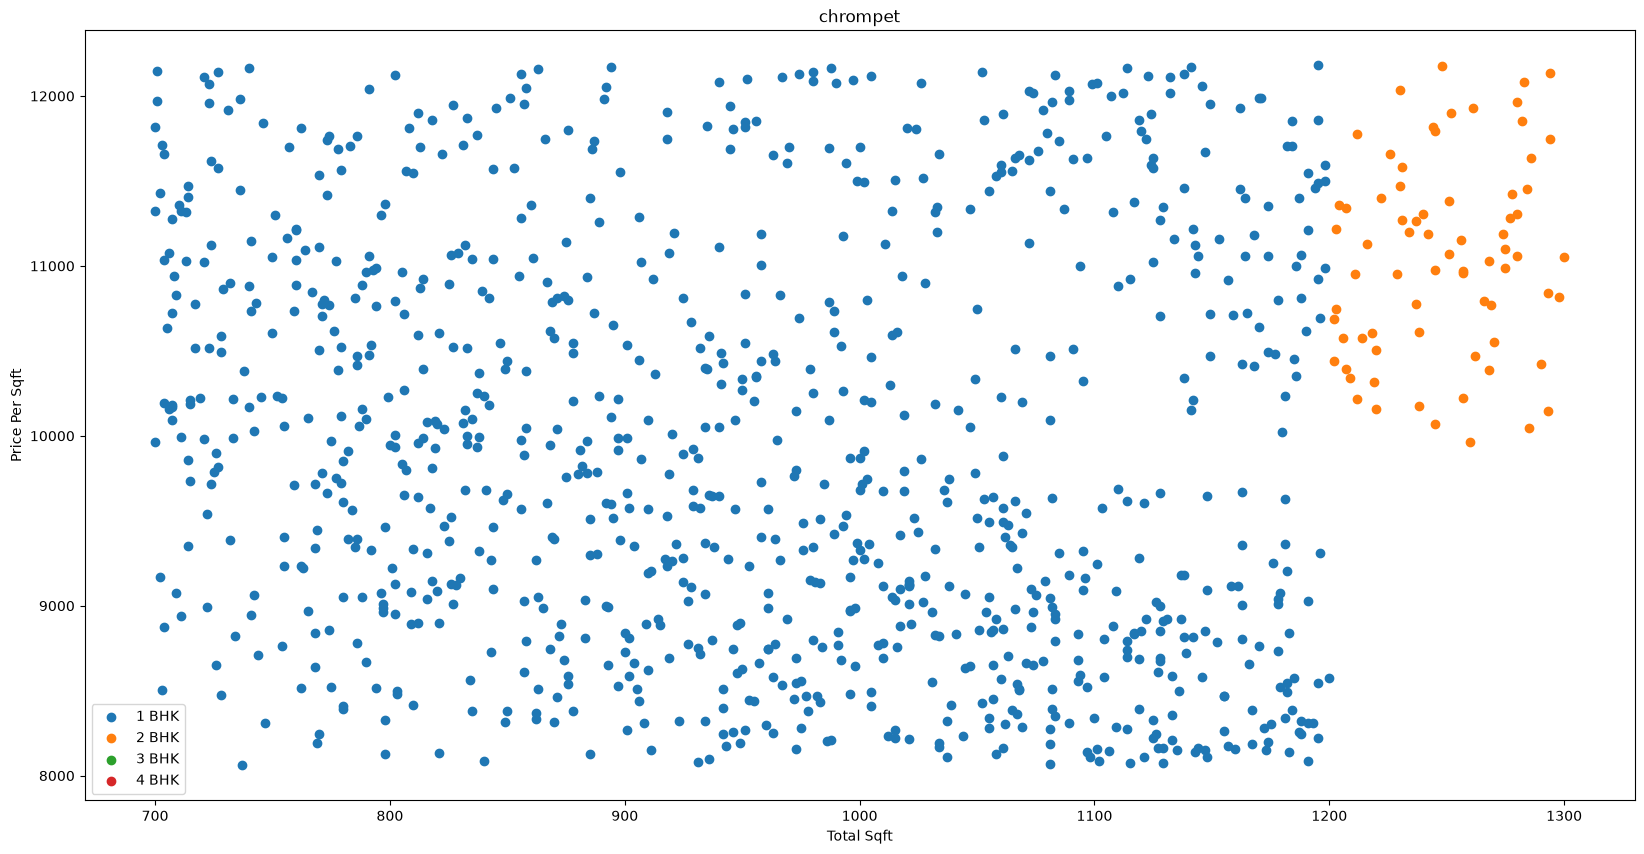

In [63]:
import matplotlib.pyplot as plt

def plot_scatter_chart(df, location):
    bhk1 = df[(df.location == location) & (df.bhk == 1)]
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    bhk4 = df[(df.location == location) & (df.bhk == 4)]

    plt.scatter(bhk1.total_sqft, bhk1.price_per_sqft, label='1 BHK')
    plt.scatter(bhk2.total_sqft, bhk2.price_per_sqft, label='2 BHK')
    plt.scatter(bhk3.total_sqft, bhk3.price_per_sqft, label='3 BHK')
    plt.scatter(bhk4.total_sqft, bhk4.price_per_sqft, label='4 BHK')

    plt.xlabel("Total Sqft")
    plt.ylabel("Price Per Sqft")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df, "chrompet")

In [64]:
df = df.drop('price_per_sqft', axis=1)

df.head()

,location,total_sqft,bhk,bath,price
0,"adayalampet, maduravoyal",1245,3,3,7719000.0
1,"adayalampet, maduravoyal",840,2,3,5500000.0
3,"adayalampet, maduravoyal",840,2,3,5600000.0
6,"adayalampet, maduravoyal",840,2,3,5500000.0
8,"adayalampet, maduravoyal",1842,3,3,12000000.0


In [65]:
df.shape

(3742, 5)

In [66]:
dummies = pd.get_dummies(df.location).astype(int)

dummies.head()

,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,chrompet,guduvancheri,karapakkam,kk nagar,...,maraimalai nagar,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
df = pd.concat([df,dummies], axis=1)
df.head()

,location,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,...,maraimalai nagar,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu
0,"adayalampet, maduravoyal",1245,3,3,7719000.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"adayalampet, maduravoyal",840,2,3,5500000.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"adayalampet, maduravoyal",840,2,3,5600000.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,"adayalampet, maduravoyal",840,2,3,5500000.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,"adayalampet, maduravoyal",1842,3,3,12000000.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
df = df.drop('location', axis=1)

df.head()

,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,maraimalai nagar,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu
0,1245,3,3,7719000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,840,2,3,5500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,840,2,3,5600000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,840,2,3,5500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1842,3,3,12000000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [69]:
df.shape

(3742, 27)

In [70]:
df.head(50)

,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,maraimalai nagar,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu
0,1245,3,3,7719000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,840,2,3,5500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,840,2,3,5600000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,840,2,3,5500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1842,3,3,12000000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,542,1,2,3500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,1600,3,3,10000000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,1056,1,1,9386490.0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12,1130,1,1,13383350.0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,730,1,1,8848285.0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [71]:
df[['total_sqft', 'bhk', 'bath', 'price']].describe()

,total_sqft,bhk,bath,price
count,3742.000000,3742.000000,3742.000000,3.742000e+03
mean,1243.794228,1.430786,1.237039,9.901400e+06
std,482.302853,0.779923,0.589661,3.799284e+06
min,375.000000,1.000000,1.000000,1.100000e+06
25%,890.250000,1.000000,1.000000,7.586494e+06
50%,1132.500000,1.000000,1.000000,9.516565e+06
75%,1606.000000,2.000000,1.000000,1.211552e+07
max,7094.000000,10.000000,6.000000,7.000000e+07


In [72]:
print("total_sqft <= 0:", (df['total_sqft'] <= 0).sum())
print("bhk <= 0:", (df['bhk'] <= 0).sum())
print("bath <= 0:", (df['bath'] <= 0).sum())
print("price <= 0:", (df['price'] <= 0).sum())

total_sqft <= 0: 0
bhk <= 0: 0
bath <= 0: 0
price <= 0: 0


In [73]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

df['sqft_per_bhk'].describe()

count    3742.000000
mean      954.442375
std       335.725108
min       115.000000
25%       731.000000
50%       884.250000
75%      1110.000000
max      2364.666667
Name: sqft_per_bhk, dtype: float64

In [74]:
df.sort_values('sqft_per_bhk').head(20)

,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu,sqft_per_bhk
3901,575,5,2,3500000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,115.000000
3962,690,6,2,6000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,115.000000
4065,1000,6,3,10000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,166.666667
4054,1069,5,3,6000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,213.800000
3740,693,3,2,3440000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,231.000000
4403,1000,4,3,8500000.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,250.000000
3102,561,2,2,5000000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,280.500000
3935,588,2,2,5900000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,294.000000
4061,889,3,3,7800000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,296.333333
3738,598,2,2,2950000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,299.000000


In [75]:
df.sort_values('sqft_per_bhk', ascending=False).head(20)

,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu,sqft_per_bhk
3854,7094,3,1,70000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,2364.666667
723,1799,1,1,13179060.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1799.000000
780,1797,1,1,13049510.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1797.000000
4235,1796,1,1,12892760.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1796.000000
925,1796,1,1,13800280.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1796.000000
817,1796,1,1,12754380.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1796.000000
709,1796,1,1,13465550.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1796.000000
4234,1795,1,1,13820610.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1795.000000
889,1794,1,1,13876620.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1794.000000
636,1794,1,1,12653630.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1794.000000


In [76]:
df[df['bath'] > df['bhk'] + 1][
    ['total_sqft', 'bhk', 'bath', 'price']
]

,total_sqft,bhk,bath,price
2153,875,1,3,3800000.0
3756,800,2,5,3600000.0
3761,980,1,3,3465000.0
3762,800,2,6,3700000.0
3768,800,2,4,3700000.0
3795,880,1,3,2728000.0
3807,4800,3,5,42000000.0
3855,1100,1,3,6000000.0
3896,800,2,4,4500000.0
3973,2962,2,4,17000000.0


In [77]:
df.shape

(3742, 28)

In [78]:
df[['total_sqft', 'bhk', 'bath', 'price']].describe()

,total_sqft,bhk,bath,price
count,3742.000000,3742.000000,3742.000000,3.742000e+03
mean,1243.794228,1.430786,1.237039,9.901400e+06
std,482.302853,0.779923,0.589661,3.799284e+06
min,375.000000,1.000000,1.000000,1.100000e+06
25%,890.250000,1.000000,1.000000,7.586494e+06
50%,1132.500000,1.000000,1.000000,9.516565e+06
75%,1606.000000,2.000000,1.000000,1.211552e+07
max,7094.000000,10.000000,6.000000,7.000000e+07


In [ ]:
df[(df['bhk'] >= 8) | (df['bath'] >= 5)]

,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu,sqft_per_bhk
3756,800,2,5,3600000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,400.000000
3762,800,2,6,3700000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,400.000000
3770,4200,4,5,29700000.0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1050.000000
3771,5500,5,5,39900000.0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1100.000000
3774,5600,5,5,39900000.0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1120.000000
3807,4800,3,5,42000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1600.000000
3923,3000,7,5,22000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,428.571429
3938,4500,5,5,27000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,900.000000
3960,5000,7,5,30000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,714.285714
3970,3212,10,1,15500000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,321.200000


In [84]:
df[df['sqft_per_bhk'] < 300]


,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu,sqft_per_bhk
3102,561,2,2,5000000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,280.500000
3738,598,2,2,2950000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,299.000000
3740,693,3,2,3440000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,231.000000
3901,575,5,2,3500000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,115.000000
3935,588,2,2,5900000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,294.000000
3962,690,6,2,6000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,115.000000
4054,1069,5,3,6000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,213.800000
4061,889,3,3,7800000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,296.333333
4065,1000,6,3,10000000.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,166.666667
4403,1000,4,3,8500000.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,250.000000


In [85]:
df = df[df['sqft_per_bhk'] >= 300]

In [86]:
df.drop('sqft_per_bhk', axis=1, inplace=True)

In [87]:
df.shape

(3732, 27)

In [88]:
df[df['bath'] > df['bhk'] + 2][
    ['total_sqft', 'bhk', 'bath', 'price']
]

,total_sqft,bhk,bath,price
3756,800,2,5,3600000.0
3762,800,2,6,3700000.0
4033,800,1,4,3700000.0


In [89]:
df = df[df['bath'] <= df['bhk'] + 2]

print(df.shape)


(3729, 27)


In [90]:
df[['total_sqft', 'bhk', 'bath', 'price']].describe()

,total_sqft,bhk,bath,price
count,3729.000000,3729.000000,3729.000000,3.729000e+03
mean,1245.431751,1.424242,1.230893,9.917122e+06
std,482.240884,0.767298,0.576777,3.794416e+06
min,375.000000,1.000000,1.000000,1.100000e+06
25%,892.000000,1.000000,1.000000,7.600500e+06
50%,1135.000000,1.000000,1.000000,9.524800e+06
75%,1609.000000,2.000000,1.000000,1.212033e+07
max,7094.000000,10.000000,5.000000,7.000000e+07


In [91]:
x = df.drop('price', axis=1)
y = df['price']

In [92]:
x.shape


(3729, 26)

In [93]:
y.shape

(3729,)

In [94]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10
)

print(x_train.shape)
print(x_test.shape)

(2983, 26)
(746, 26)


In [95]:
def check_bhk_outliers(df):
    outliers = []

    for location, location_df in df.groupby('location'):
        bhk_stats = location_df.groupby('bhk')['price_per_sqft'].mean()

        for bhk in bhk_stats.index:
            if bhk + 1 in bhk_stats.index:
                lower_price = bhk_stats[bhk]
                higher_price = bhk_stats[bhk + 1]

                if lower_price > higher_price:
                    outliers.append({
                        'location': location,
                        'lower_bhk': bhk,
                        'higher_bhk': bhk + 1,
                        'lower_bhk_price_per_sqft': lower_price,
                        'higher_bhk_price_per_sqft': higher_price
                    })

    return pd.DataFrame(outliers)

In [96]:
bhk_outliers = check_bhk_outliers(df)

bhk_outliers

KeyError: 'location'

In [97]:
df.columns

Index(['total_sqft', 'bhk', 'bath', 'price', 'adayalampet, maduravoyal',
       'adyar', 'anna nagar', 'anna nagar, chengalpattu', 'avadi',
       'chettipunyam', 'chrompet', 'guduvancheri', 'karapakkam', 'kk nagar',
       'kundrathur', 'madambakkam', 'mahindra world city', 'maraimalai nagar',
       'muttukadu', 'oragadam sriperambattur', 'other', 'padur', 't nagar',
       'thirumangalam, anna nagar west', 'urapakkam', 'velachery',
       'veppampattu'],
      dtype='str')

In [98]:
df[['total_sqft', 'bhk', 'bath', 'price']].describe()

,total_sqft,bhk,bath,price
count,3729.000000,3729.000000,3729.000000,3.729000e+03
mean,1245.431751,1.424242,1.230893,9.917122e+06
std,482.240884,0.767298,0.576777,3.794416e+06
min,375.000000,1.000000,1.000000,1.100000e+06
25%,892.000000,1.000000,1.000000,7.600500e+06
50%,1135.000000,1.000000,1.000000,9.524800e+06
75%,1609.000000,2.000000,1.000000,1.212033e+07
max,7094.000000,10.000000,5.000000,7.000000e+07


In [99]:
print("Largest properties:")
display(
    df.nlargest(15, 'total_sqft')
    [['total_sqft', 'bhk', 'bath', 'price']]
)

print("\nHighest BHK:")
display(
    df.nlargest(15, 'bhk')
    [['total_sqft', 'bhk', 'bath', 'price']]
)

print("\nHighest prices:")
display(
    df.nlargest(15, 'price')
    [['total_sqft', 'bhk', 'bath', 'price']]
)


Largest properties:


,total_sqft,bhk,bath,price
3854,7094,3,1,70000000.0
3766,6000,7,4,25000000.0
3993,6000,9,1,45000000.0
3774,5600,5,5,39900000.0
3771,5500,5,5,39900000.0
3960,5000,7,5,30000000.0
3807,4800,3,5,42000000.0
3938,4500,5,5,27000000.0
3770,4200,4,5,29700000.0
3862,3600,7,1,22500000.0



Highest BHK:


,total_sqft,bhk,bath,price
3970,3212,10,1,15500000.0
3993,6000,9,1,45000000.0
4037,3000,8,5,19000000.0
3766,6000,7,4,25000000.0
3862,3600,7,1,22500000.0
3923,3000,7,5,22000000.0
3960,5000,7,5,30000000.0
3904,3000,6,4,19700000.0
4046,2400,6,4,20000000.0
2154,2000,5,3,8500000.0



Highest prices:


,total_sqft,bhk,bath,price
3854,7094,3,1,70000000.0
3993,6000,9,1,45000000.0
3807,4800,3,5,42000000.0
3771,5500,5,5,39900000.0
3774,5600,5,5,39900000.0
3913,2850,4,4,32500000.0
3960,5000,7,5,30000000.0
4397,2661,4,4,30000000.0
3770,4200,4,5,29700000.0
3938,4500,5,5,27000000.0


In [100]:
df['price_per_sqft_check'] = df['price'] / df['total_sqft']

display(
    df.nlargest(20, 'price_per_sqft_check')
    [['total_sqft', 'bhk', 'bath', 'price', 'price_per_sqft_check']]
)

,total_sqft,bhk,bath,price,price_per_sqft_check
1776,1195,1,1,14554600.0,12179.581590
247,1078,1,1,13128785.0,12178.835807
1863,1248,2,1,15195150.0,12175.600962
274,1299,2,2,15815700.0,12175.288684
1089,894,1,1,10882400.0,12172.706935
1131,1141,1,1,13883800.0,12168.098160
1384,740,1,1,9002750.0,12165.878378
370,836,1,1,10170565.0,12165.747608
2010,988,1,1,12019650.0,12165.637652
1379,1114,1,1,13551850.0,12165.035907


In [104]:
display(
    df.nsmallest(20, 'price_per_sqft_check')
    [['total_sqft', 'bhk', 'bath', 'price', 'price_per_sqft_check']]
)

KeyError: 'price_per_sqft_check'

In [102]:
df.drop('price_per_sqft_check', axis=1, inplace=True)

In [103]:
df

,total_sqft,bhk,bath,price,"adayalampet, maduravoyal",adyar,anna nagar,"anna nagar, chengalpattu",avadi,chettipunyam,...,maraimalai nagar,muttukadu,oragadam sriperambattur,other,padur,t nagar,"thirumangalam, anna nagar west",urapakkam,velachery,veppampattu
0,1245,3,3,7719000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,840,2,3,5500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,840,2,3,5600000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,840,2,3,5500000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1842,3,3,12000000.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5023,999,2,3,4000000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5025,966,2,3,3850000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5029,850,2,3,3600000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5030,860,1,3,3000000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [105]:
display(
    df.sort_values(['bhk', 'total_sqft'], ascending=[False, True])
      [['total_sqft', 'bhk', 'bath', 'price']]
      .head(25)
)

,total_sqft,bhk,bath,price
3970,3212,10,1,15500000.0
3993,6000,9,1,45000000.0
4037,3000,8,5,19000000.0
3923,3000,7,5,22000000.0
3862,3600,7,1,22500000.0
3960,5000,7,5,30000000.0
3766,6000,7,4,25000000.0
4046,2400,6,4,20000000.0
3904,3000,6,4,19700000.0
2154,2000,5,3,8500000.0


In [106]:
display(
    df[df['bhk'] >= 5]
    [['total_sqft', 'bhk', 'bath', 'price']]
    .sort_values('bhk', ascending=False)
)

,total_sqft,bhk,bath,price
3970,3212,10,1,15500000.0
3993,6000,9,1,45000000.0
4037,3000,8,5,19000000.0
3766,6000,7,4,25000000.0
3862,3600,7,1,22500000.0
3923,3000,7,5,22000000.0
3960,5000,7,5,30000000.0
3904,3000,6,4,19700000.0
4046,2400,6,4,20000000.0
2154,2000,5,3,8500000.0


In [108]:
display(
    df[df['bhk'] >= 5]
    [['total_sqft', 'bhk', 'bath', 'price']]
    .sort_values(['bhk', 'total_sqft'], ascending=[False, True])
)


,total_sqft,bhk,bath,price
3970,3212,10,1,15500000.0
3993,6000,9,1,45000000.0
4037,3000,8,5,19000000.0
3923,3000,7,5,22000000.0
3862,3600,7,1,22500000.0
3960,5000,7,5,30000000.0
3766,6000,7,4,25000000.0
4046,2400,6,4,20000000.0
3904,3000,6,4,19700000.0
2154,2000,5,3,8500000.0


In [109]:
df = df[
    ~(
        ((df['bhk'] >= 7) & (df['bath'] <= 1)) |
        ((df['bhk'] >= 5) & (df['bath'] <= 1))
    )
]

In [110]:
df = df[~((df['bhk'] >= 5) & (df['bath'] <= 1))]

In [111]:
df[['total_sqft', 'bhk', 'bath', 'price']].describe()

,total_sqft,bhk,bath,price
count,3724.000000,3724.000000,3724.000000,3.724000e+03
mean,1241.998657,1.416488,1.231203,9.897274e+06
std,471.597185,0.734227,0.577102,3.738562e+06
min,375.000000,1.000000,1.000000,1.100000e+06
25%,892.000000,1.000000,1.000000,7.600000e+06
50%,1134.000000,1.000000,1.000000,9.522255e+06
75%,1606.000000,2.000000,1.000000,1.211537e+07
max,7094.000000,8.000000,5.000000,7.000000e+07


In [112]:
display(
    df[df['price'] >= 50000000]
    [['total_sqft', 'bhk', 'bath', 'price']]
)

,total_sqft,bhk,bath,price
3854,7094,3,1,70000000.0


In [113]:
df = df.drop(index=3854)

In [114]:
df.reset_index(drop=True, inplace=True)

In [115]:
from sklearn.model_selection import train_test_split

x = df.drop('price', axis=1)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=10
)

print(x_train.shape)
print(x_test.shape)

(2978, 26)
(745, 26)


In [116]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(x_train, y_train)
lr_clf.score(x_test, y_test)

0.8293654942901826

In [117]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
cv = ShuffleSplit(n_splits=5, test_size=0.25, random_state=0)
cross_val_score(LinearRegression(), x, y, cv=cv)

array([0.84609173, 0.83507001, 0.81755547, 0.84572409, 0.85271874])

In [118]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
import pandas as pd


def find_best_model_using_gridsearchcv(x, y):

    algos = {

        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                # normalize was removed from LinearRegression
            }
        },

        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },

        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }

    scores = []

    cv = ShuffleSplit(
        n_splits=5,
        test_size=0.25,
        random_state=0
    )

    for algo_name, config in algos.items():

        gs = GridSearchCV(
            config['model'],
            config['params'],
            cv=cv,
            return_train_score=False
        )

        gs.fit(x, y)

        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(
        scores,
        columns=['model', 'best_score', 'best_params']
    )

In [119]:
find_best_model_using_gridsearchcv(x, y)

/Users/irfankhan/dev/HPP/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.752683e+15, tolerance: 3.704e+12
  model = cd_fast.enet_coordinate_descent(
/Users/irfankhan/dev/HPP/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.592355e+15, tolerance: 3.588e+12
  model = cd_fast.enet_coordinate_descent(
/Users/irfankhan/dev/HPP/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

,model,best_score,best_params
0,linear_regression,0.839432,{}
1,lasso,0.839432,"{'alpha': 2, 'selection': 'random'}"
2,decision_tree,0.765274,"{'criterion': 'squared_error', 'splitter': 'ra..."


In [122]:
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(x.columns==location)[0][0]
    xx = np.zeros(len(x.columns))
    xx[0] = sqft
    xx[1] = bath
    xx[2] = bhk
    if loc_index >= 0:
        xx[loc_index] = 1
    return lr_clf.predict([xx])[0] / 100000

In [123]:
predict_price('adyar', 1000, 2, 2)

/Users/irfankhan/dev/HPP/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(106.4093745678325)

In [124]:
import pickle

with open('../model/chennai/chennai_home_price_predictor.pickle', 'wb') as f:
    pickle.dump(lr_clf, f)

In [125]:
import json

columns = {
    'data_columns': [col.lower() for col in x.columns]
}

with open('../model/chennai/chennai_columns.json', 'w') as f:
    json.dump(columns, f)